In [1]:
import json

with open("../data/curated_gcp_marks.json") as f:
    labels = json.load(f)

print("Total images:", len(labels))

# see one example
first_key = list(labels.keys())[0]
print(first_key)
print(labels[first_key])

Total images: 1000
Kemerton/240222/XLGC1028 230823/DJI_20240222135055_0537.JPG
{'mark': {'x': 2461.370441643842, 'y': 956.8182852908321}, 'verified_shape': 'Cross'}


(np.float64(-0.5), np.float64(4095.5), np.float64(2729.5), np.float64(-0.5))

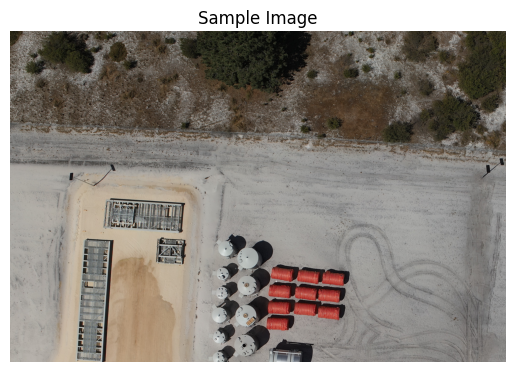

In [4]:
import cv2
import matplotlib.pyplot as plt

img_path = "../data/train_dataset/" + first_key

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")

(np.float64(-0.5), np.float64(4095.5), np.float64(2729.5), np.float64(-0.5))

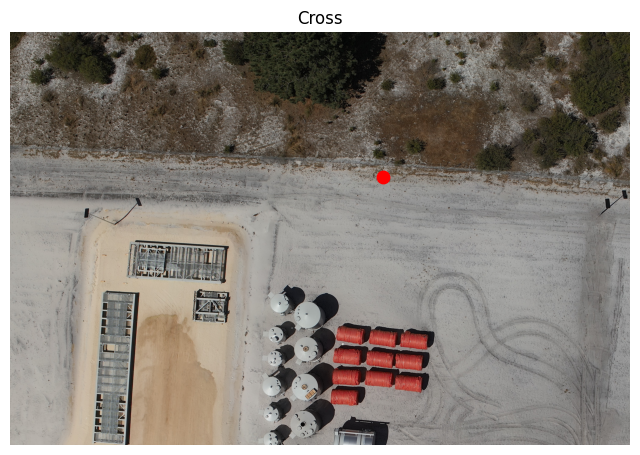

In [5]:
x = labels[first_key]["mark"]["x"]
y = labels[first_key]["mark"]["y"]

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.scatter(x, y, c="red", s=80)
plt.title(labels[first_key]["verified_shape"])
plt.axis("off")

In [7]:
from collections import Counter

shapes = [labels[k]["verified_shape"]
          for k in labels
          if "verified_shape" in labels[k]]

Counter(shapes)

Counter({'Square': 892, 'Cross': 105})

In [8]:
missing = [k for k in labels if "verified_shape" not in labels[k]]

print("Missing shape labels:", len(missing))

Missing shape labels: 3


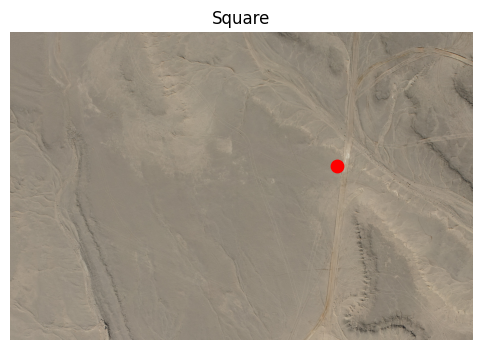

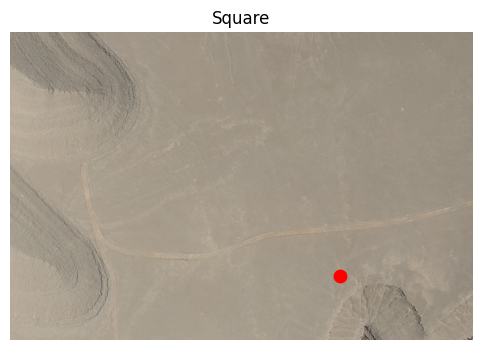

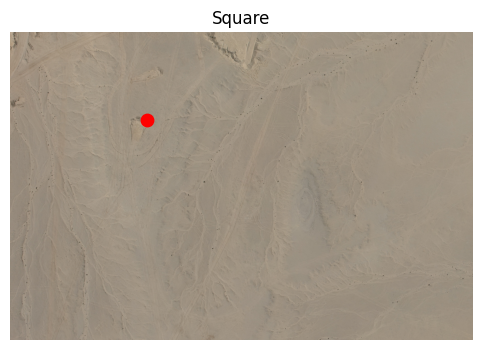

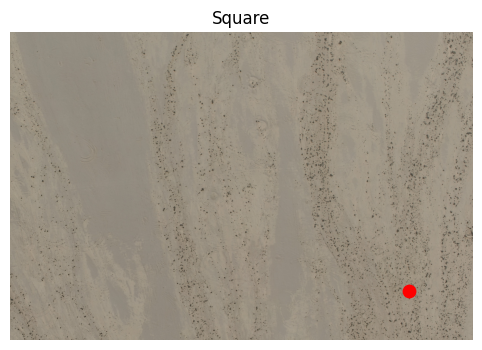

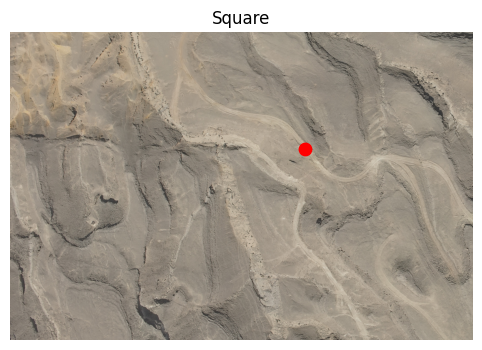

In [9]:
import random
import cv2
import matplotlib.pyplot as plt

samples = random.sample(list(labels.keys()), 5)

for key in samples:

    img_path = "../data/train_dataset/" + key
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x = labels[key]["mark"]["x"]
    y = labels[key]["mark"]["y"]

    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.scatter(x,y,c="red",s=80)
    plt.title(labels[key].get("verified_shape"))
    plt.axis("off")

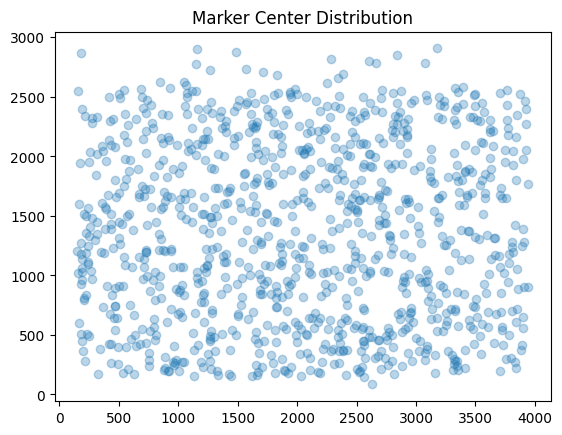

In [10]:
xs = [labels[k]["mark"]["x"] for k in labels]
ys = [labels[k]["mark"]["y"] for k in labels]

plt.scatter(xs, ys, alpha=0.3)
plt.title("Marker Center Distribution")
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

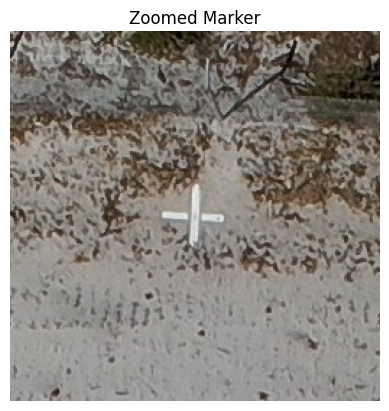

In [11]:
key = list(labels.keys())[0]

img = cv2.imread("../data/train_dataset/" + key)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = int(labels[key]["mark"]["x"])
y = int(labels[key]["mark"]["y"])

crop = img[y-128:y+128, x-128:x+128]

plt.imshow(crop)
plt.title("Zoomed Marker")
plt.axis("off")

Dataset Observations

• The dataset contains 1000 aerial images.

• Image resolution is approximately 4096 × 2730.

• Marker centers are distributed across the entire image.

• The marker occupies a very small region relative to the full image.

• The dataset is highly imbalanced (Square ≈ 892, Cross ≈ 105).

• A few samples are missing the `verified_shape` label.

Implications for modelling

• A regression model will be used to predict the marker center (x, y).

• Cropping around the predicted center can simplify shape classification.

• Class imbalance should be handled using class weighting or sampling.